# Visualize trained MPN weights across learning rules

Reload the networks saved by `train_mpn.py` (one seed, each learning rule) and
compare the learned **weight matrices `W`** (not the data-dependent modulation
`M`):

| Component | Parameter | Shape | Role |
|---|---|---|---|
| **Input layer** | `mp_layer.W` | `(n_hidden, n_input)` | input → hidden (no separate embedding layer in `mpn1`) |
| **Output layer** | `W_output` | `(n_output, n_hidden)` | hidden → readout |

Set `SEED` and `RULES` below to match a completed `train_mpn.py` run (the
checkpoint filenames encode task / hidden / batch / steps / lr / feedback).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import _bootstrap  # noqa: F401  -- prepends ./core to sys.path
import mpn_tasks
import mpn
import train_mpn as tm

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 1. Choose the run to load

`SEED` picks which trained network (seeds were `tm.SEED + k`). `RULES` must be a
subset of what `train_mpn.py` actually saved. The checkpoint path is built by
`tm.ckpt_path(rule, seed)` from the current `train_mpn` config — so if you
changed hidden size / steps / etc. for the run, set them on `tm` here first.

In [2]:
# --- run selection ---
SEED = tm.SEED            # e.g. 42; use tm.SEED + k for the k-th run
RULES = ["bptt", "local_diag_rflo", "local_direct"]  # rules to compare

# If the saved run used non-default config, override tm.* here BEFORE loading,
# e.g.  tm.N_HIDDEN = 200; tm.N_DATASETS = 5000
DEVICE = torch.device("cpu")

nets = {}
for rule in RULES:
    path = tm.ckpt_path(rule, SEED)
    nets[rule] = tm.load_net(path, device=DEVICE)
    print(f"{rule:20} <- {path}")

n_input = nets[RULES[0]].n_input
n_hidden = nets[RULES[0]].n_hidden
n_output = nets[RULES[0]].n_output
print(f"\nn_input={n_input}  n_hidden={n_hidden}  n_output={n_output}")

bptt                 <- checkpoints/mpn_delaygo_h200_b128_n5000_lr1e-03_exact_readout_bptt_seed42.pt
local_diag_rflo      <- checkpoints/mpn_delaygo_h200_b128_n5000_lr1e-03_exact_readout_local_diag_rflo_seed42.pt
local_direct         <- checkpoints/mpn_delaygo_h200_b128_n5000_lr1e-03_exact_readout_local_direct_seed42.pt

n_input=6  n_hidden=200  n_output=3


## 2. Extract the trained weight matrices

We visualize the learned **weights `W`** only (not the data-dependent
modulation `M`). For `mpn1` there are two trainable weight matrices:
`mp_layer.W` is the input→hidden layer (there is no separate input-embedding
layer), and `W_output` is the hidden→output readout.

In [3]:
comp = {}   # comp[rule] = {'W_in', 'W_out'}
for rule, net in nets.items():
    W_in = net.mp_layer.W.detach().cpu().numpy()   # (n_hidden, n_input)
    W_out = net.W_output.detach().cpu().numpy()    # (n_output, n_hidden)
    comp[rule] = {"W_in": W_in, "W_out": W_out}
    print(f"{rule:20} |W_in| {np.abs(W_in).mean():.3e}  "
          f"|W_out| {np.abs(W_out).mean():.3e}")

bptt                 |W_in| 9.770e-02  |W_out| 9.121e-02
local_diag_rflo      |W_in| 8.738e-02  |W_out| 8.942e-02
local_direct         |W_in| 9.226e-02  |W_out| 9.829e-02


## 3. Weight heatmaps — one row per learning rule

Columns: **input layer** `mp_layer.W` and **output layer** `W_output`. A shared
symmetric color scale per column makes rules directly comparable.

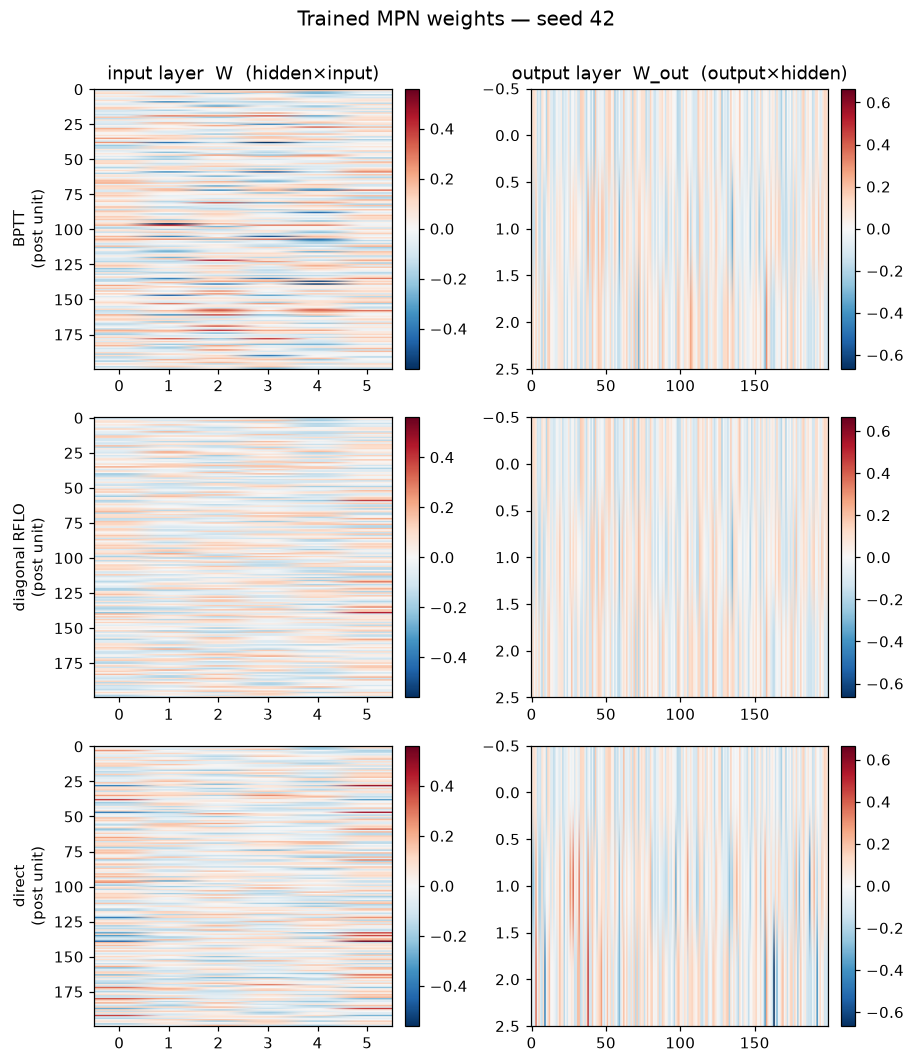

In [4]:
cols = [("W_in", "input layer  W  (hidden×input)"),
        ("W_out", "output layer  W_out  (output×hidden)")]

# Shared symmetric vlim per column (comparable across rules).
vlim = {}
for key, _ in cols:
    m = max(np.abs(comp[r][key]).max() for r in RULES)
    vlim[key] = m

nrows, ncols = len(RULES), len(cols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows),
                         squeeze=False)
for i, rule in enumerate(RULES):
    for j, (key, title) in enumerate(cols):
        ax = axes[i][j]
        v = vlim[key]
        im = ax.imshow(comp[rule][key], aspect="auto", cmap="RdBu_r",
                       vmin=-v, vmax=v)
        if i == 0:
            ax.set_title(title)
        if j == 0:
            ax.set_ylabel(f"{tm.RULE_LABEL.get(rule, rule)}\n(post unit)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Trained MPN weights — seed {SEED}", y=1.002, fontsize=13)
fig.tight_layout()
plt.show()